## cifar10 and fab norm

In [4]:
import pandas
import os

print(os.getcwd())
standard_df = pandas.read_csv("results/resnet20_checkpoint_evaluations.csv")
weight_decay_df = pandas.read_csv("results/resnet20_weightdecay_checkpoint_evaluations.csv")


/project/nr_haml2025/endomet/irwl1-adaptation


In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

anchor_points = np.array([0, 22, 38, 45, 54, 62, 70, 76, 85, 90, 95], dtype=float)

def nearest_anchor(values):
    values = np.asarray(values, dtype=float)
    nearest_indices = np.abs(values[:, None] - anchor_points[None, :]).argmin(axis=1)
    return anchor_points[nearest_indices]


def summarize_by_anchor(frame):
    non_feature_columns = {
        "checkpoint_path",
        "run_dir",
        "checkpoint_index",
        "phase",
        "sparsity",
        "fab_accuracy",
    }
    metric_columns = [column for column in frame.columns if column not in non_feature_columns]

    agg_spec = {}
    for column in metric_columns:
        agg_spec[f"{column}_mean"] = (column, "mean")
        agg_spec[f"{column}_std"] = (column, "std")

    return (
        frame.assign(sparsity_bucket=nearest_anchor(frame["sparsity"].to_numpy()))
        .groupby("sparsity_bucket", as_index=False)
        .agg(**agg_spec)
        .sort_values("sparsity_bucket")
        .reset_index(drop=True)
    )


def plot_mean_with_std(ax, summary, x_column, mean_column, std_column, label, color):
    x_values = summary[x_column].to_numpy()
    mean_values = summary[mean_column].to_numpy()
    std_values = summary[std_column].fillna(0).to_numpy()
    ax.plot(x_values, mean_values, color=color, marker="o", linewidth=2, label=label)
    ax.fill_between(x_values, mean_values - std_values, mean_values + std_values, color=color, alpha=0.2, label="\u00b11 std")


standard_bucketed_summary = summarize_by_anchor(standard_df)
weight_decay_bucketed_summary = summarize_by_anchor(weight_decay_df)

standard_bucketed_summary


,sparsity_bucket,test_accuracy_mean,test_accuracy_std,fab_norm_mean,fab_norm_std,brightness_mean,brightness_std,contrast_mean,contrast_std,defocus_blur_mean,...,shot_noise_mean,shot_noise_std,snow_mean,snow_std,spatter_mean,spatter_std,speckle_noise_mean,speckle_noise_std,zoom_blur_mean,zoom_blur_std
0,0.0,75.902000,0.748445,0.120991,0.016296,26.924000,0.857040,47.608800,2.619483,35.016400,...,42.307200,3.542644,38.338400,2.679626,32.810800,1.828388,42.149600,3.436320,40.733200,1.729608
1,22.0,77.108000,1.542861,0.123494,0.015571,25.642000,1.813101,52.167200,3.253437,34.718400,...,43.387600,4.405125,38.850000,2.296132,31.878400,2.081834,42.725200,4.228545,40.083200,3.946465
2,38.0,76.680000,0.802496,0.104369,0.007291,26.495200,0.972762,52.408800,1.826661,36.273600,...,46.060000,4.067035,40.039600,2.243207,31.981600,0.953825,44.884000,3.463094,42.571200,3.287784
3,45.0,75.900000,NaN,0.101232,NaN,27.372000,NaN,54.940000,NaN,36.176000,...,52.584000,NaN,39.018000,NaN,33.454000,NaN,51.728000,NaN,42.760000,NaN
4,54.0,75.708000,1.500173,0.095255,0.015834,27.127200,1.872116,51.613200,1.116545,36.260800,...,50.462400,9.154095,41.426800,1.976818,32.466000,1.930705,49.152800,8.631526,42.168400,3.085700
5,62.0,75.564000,0.270518,0.095074,0.015690,27.676400,0.700219,53.451600,1.038037,35.643200,...,52.862800,8.631072,42.908800,2.078260,32.934800,0.999749,51.314000,7.767085,41.711200,1.824744
6,70.0,74.430000,1.950461,0.085692,0.013432,28.400000,2.555756,53.640000,3.544222,37.830800,...,52.467200,8.147775,42.312800,3.953191,33.577200,2.493520,50.607600,7.517671,44.394000,2.391750
7,76.0,73.328000,1.132727,0.080534,0.010885,29.868000,1.152712,54.950000,1.472877,39.199600,...,54.740800,8.281683,43.435600,3.072154,34.618000,2.010829,53.264400,7.426810,45.581600,2.169132
8,85.0,71.035000,2.153688,0.074081,0.011868,32.452750,2.270652,57.584750,1.441992,40.719750,...,56.225250,7.953919,45.329000,3.059699,36.049250,2.045807,54.870500,7.400407,46.563500,2.408469
9,90.0,68.396667,1.214921,0.066261,0.003405,35.110667,1.764189,59.647333,2.272747,42.833333,...,61.258667,7.013894,46.738667,2.278117,37.992667,2.738528,59.680667,6.116432,48.142667,2.315323


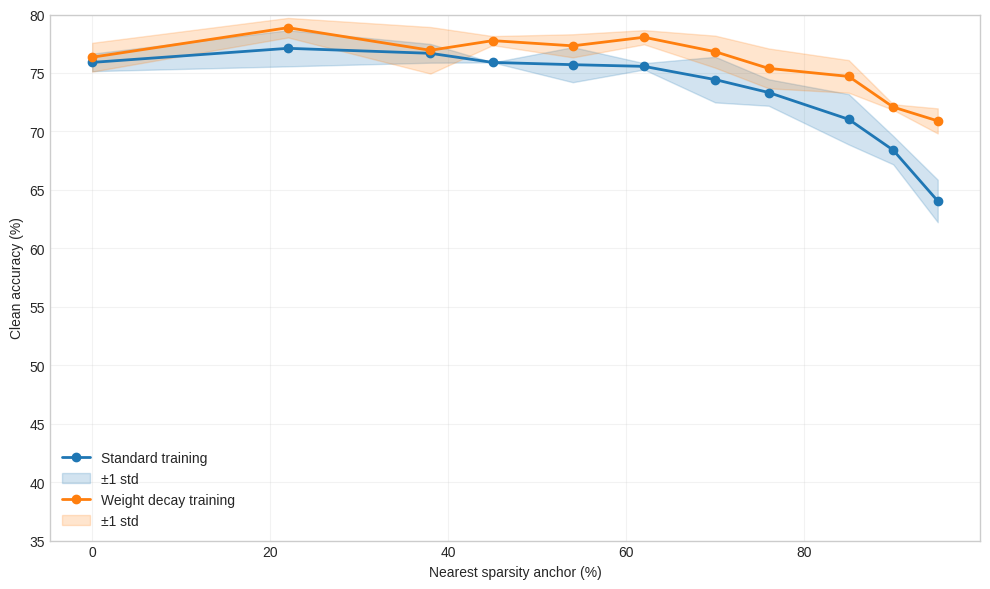

In [11]:
test_summary = (
    standard_bucketed_summary[["sparsity_bucket", "test_accuracy_mean", "test_accuracy_std"]]
    .dropna(subset=["sparsity_bucket"])
    .sort_values("sparsity_bucket")
    .reset_index(drop=True)
)

weight_decay_test_summary = (
    weight_decay_bucketed_summary[["sparsity_bucket", "test_accuracy_mean", "test_accuracy_std"]]
    .dropna(subset=["sparsity_bucket"])
    .sort_values("sparsity_bucket")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
plot_mean_with_std(ax, test_summary, "sparsity_bucket", "test_accuracy_mean", "test_accuracy_std", "Standard training", "tab:blue")
plot_mean_with_std(ax, weight_decay_test_summary, "sparsity_bucket", "test_accuracy_mean", "test_accuracy_std", "Weight decay training", "tab:orange")
#ax.set_title("Clean accuracy by nearest sparsity anchor")
ax.set_xlabel("Nearest sparsity anchor (%)")
ax.set_ylabel("Clean accuracy (%)")
ax.set_ylim(35, 80)
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()


In [7]:
fab_summary = (
    standard_bucketed_summary[["sparsity_bucket", "fab_norm_mean", "fab_norm_std"]]
    .dropna(subset=["sparsity_bucket"])
    .sort_values("sparsity_bucket")
    .reset_index(drop=True)
)

weight_decay_fab_summary = (
    weight_decay_bucketed_summary[["sparsity_bucket", "fab_norm_mean", "fab_norm_std"]]
    .dropna(subset=["sparsity_bucket"])
    .sort_values("sparsity_bucket")
    .reset_index(drop=True)
)

fab_summary


,sparsity_bucket,fab_norm_mean,fab_norm_std
0,0.0,0.120991,0.016296
1,22.0,0.123494,0.015571
2,38.0,0.104369,0.007291
3,45.0,0.101232,NaN
4,54.0,0.095255,0.015834
5,62.0,0.095074,0.015690
6,70.0,0.085692,0.013432
7,76.0,0.080534,0.010885
8,85.0,0.074081,0.011868
9,90.0,0.066261,0.003405


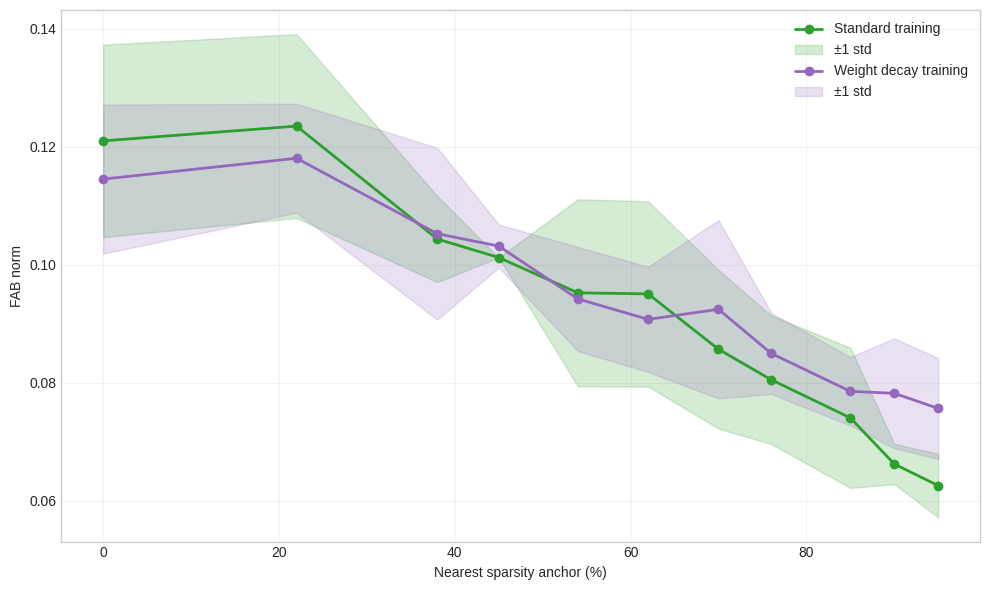

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_mean_with_std(ax, fab_summary, "sparsity_bucket", "fab_norm_mean", "fab_norm_std", "Standard training", "tab:green")
plot_mean_with_std(ax, weight_decay_fab_summary, "sparsity_bucket", "fab_norm_mean", "fab_norm_std", "Weight decay training", "tab:purple")
#ax.set_title("Norm of the minimal adversarial perturbation by nearest sparsity anchor")
ax.set_xlabel("Nearest sparsity anchor (%)")
ax.set_ylabel("FAB norm")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()


In [9]:
corruption_category_map = {
    "weather": ["brightness", "fog", "frost", "snow"],
    "noise": ["gaussian_noise", "impulse_noise", "shot_noise", "speckle_noise"],
    "blur": ["defocus_blur", "gaussian_blur", "glass_blur", "motion_blur", "zoom_blur"],
    "digital": ["contrast", "elastic_transform", "jpeg_compression", "pixelate", "saturate", "spatter"],
}


def summarize_corruption_categories(frame):
    category_error_frame = frame.assign(sparsity_bucket=nearest_anchor(frame["sparsity"].to_numpy()))
    for category, columns in corruption_category_map.items():
        category_error_frame[f"{category}_accuracy"] = 100 - category_error_frame[columns].mean(axis=1)

    return (
        category_error_frame[
            ["sparsity_bucket", *[f"{category}_accuracy" for category in corruption_category_map]]
        ]
        .groupby("sparsity_bucket", as_index=False)
        .agg(
            **{
                f"{category}_error_mean": (f"{category}_accuracy", "mean")
                for category in corruption_category_map
            },
            **{
                f"{category}_error_std": (f"{category}_accuracy", "std")
                for category in corruption_category_map
            },
        )
        .sort_values("sparsity_bucket")
        .reset_index(drop=True)
    )


corruption_category_summary = summarize_corruption_categories(standard_df)
weight_decay_corruption_category_summary = summarize_corruption_categories(weight_decay_df)

corruption_category_summary


,sparsity_bucket,weather_error_mean,noise_error_mean,blur_error_mean,digital_error_mean,weather_error_std,noise_error_std,blur_error_std,digital_error_std
0,0.0,65.570300,54.334600,58.463040,65.529400,1.767552,3.279423,1.796423,0.658064
1,22.0,65.150300,54.378000,57.610160,64.297933,2.470619,3.935733,3.377118,1.753079
2,38.0,64.030800,52.968400,55.773040,63.522400,1.663132,3.733339,2.758883,1.068528
3,45.0,63.596500,46.526000,55.697600,63.920667,NaN,NaN,NaN,NaN
4,54.0,63.229000,49.166200,56.247680,63.447267,2.006234,7.599051,2.560039,1.334345
5,62.0,61.864100,47.582700,56.219360,63.008467,1.093364,7.046890,1.607746,0.600248
6,70.0,61.449500,47.675700,54.441440,62.221067,3.348940,6.782738,1.713096,2.407622
7,76.0,59.816100,45.739500,53.830880,61.055200,1.950833,7.122693,2.661475,1.525193
8,85.0,57.459125,44.295000,52.701750,59.134500,2.533839,6.420179,2.286588,1.646819
9,90.0,55.293667,40.261667,51.397867,57.075111,0.685130,5.929278,3.023664,0.647786


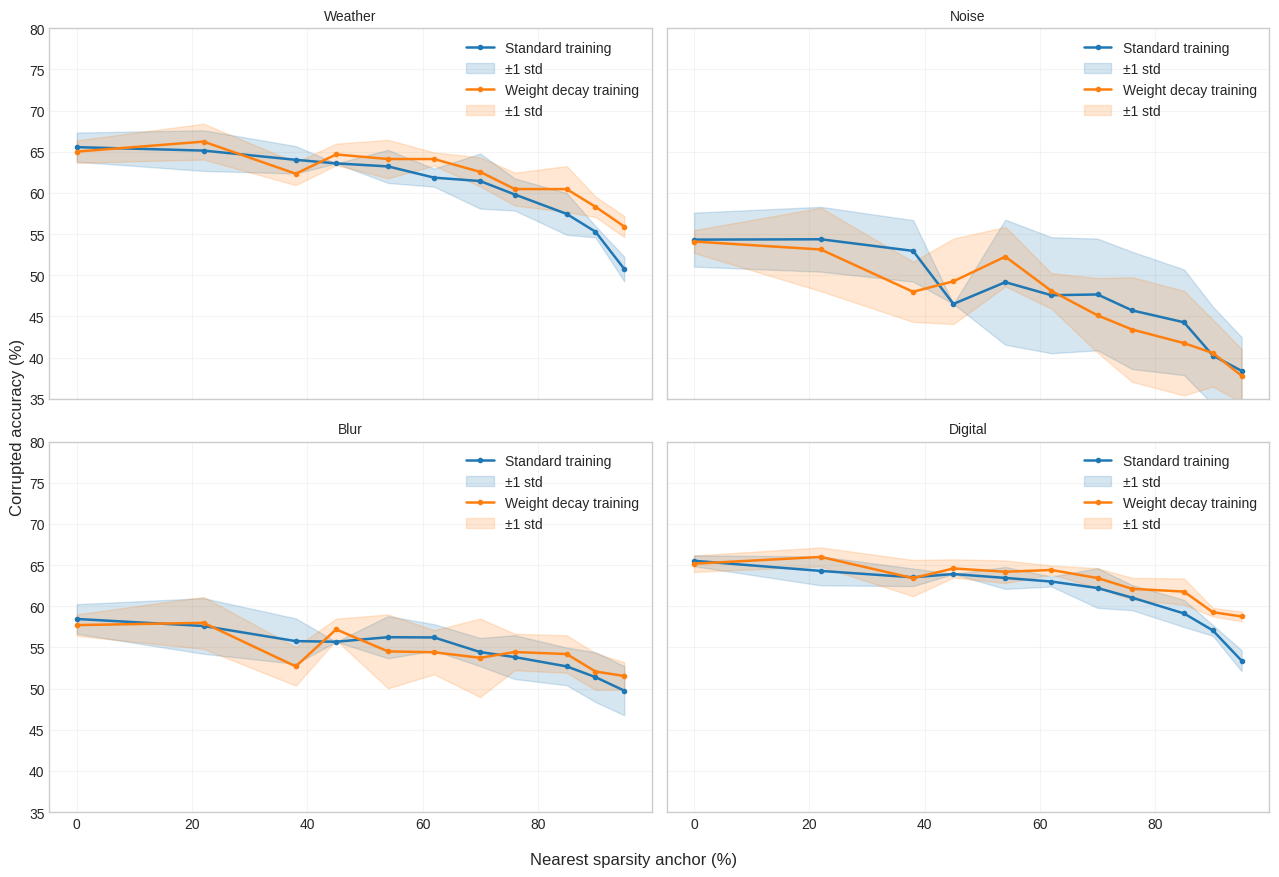

In [10]:
n_cols = 2
n_rows = (len(corruption_category_map) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 9), sharex=True, sharey=True)
axes = axes.flatten()

sparsity_values = corruption_category_summary["sparsity_bucket"].to_numpy()
weight_decay_sparsity_values = weight_decay_corruption_category_summary["sparsity_bucket"].to_numpy()

for axis, category in zip(axes, corruption_category_map):
    mean_column = f"{category}_error_mean"
    std_column = f"{category}_error_std"
    mean_values = corruption_category_summary[mean_column].to_numpy()
    std_values = corruption_category_summary[std_column].fillna(0).to_numpy()
    weight_decay_mean_values = weight_decay_corruption_category_summary[mean_column].to_numpy()
    weight_decay_std_values = weight_decay_corruption_category_summary[std_column].fillna(0).to_numpy()

    axis.plot(sparsity_values, mean_values, linewidth=1.8, marker="o", markersize=3, label="Standard training", color="tab:blue")
    axis.fill_between(sparsity_values, mean_values - std_values, mean_values + std_values, alpha=0.18, label="\u00b11 std", color="tab:blue")
    axis.plot(weight_decay_sparsity_values, weight_decay_mean_values, linewidth=1.8, marker="o", markersize=3, label="Weight decay training", color="tab:orange")
    axis.fill_between(weight_decay_sparsity_values, weight_decay_mean_values - weight_decay_std_values, weight_decay_mean_values + weight_decay_std_values, alpha=0.18, label="\u00b11 std", color="tab:orange")
    axis.set_title(category.title(), fontsize=10)
    axis.set_ylim(35, 80)
    axis.grid(alpha=0.2)
    axis.legend(frameon=False)

for axis in axes[len(corruption_category_map):]:
    axis.axis("off")

#fig.suptitle("Accuracy on CIFAR-10-C per corruption type", y=0.995)
fig.supxlabel("Nearest sparsity anchor (%)")
fig.supylabel("Corrupted accuracy (%)")
fig.tight_layout(rect=[0, 0, 1, 0.98])
